# Projeto Final de Modelos Avançados

**Objetivo do Projeto:**

O objetivo deste projeto é realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means, além de técnicas de exploração de dados, pré-processamento, implementação e avaliação de modelos.

Nossa variável alvo será a "Spending Score", uma nota de 1 a 100 que indica o comportamento de gastos do cliente.

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from plotly.subplots import make_subplots



## Análise Exploratória dos Dados
### Análise Exploratória - Geral


In [3]:
df = pd.read_csv("Mall_Customers.csv", delimiter=',')
df_original = df.copy()
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


Como mostram os dados acima e abaixo, a base possui  colunas, como o esperado, e 200 linhas. O número de dados é pequeno, o que pode resultar em um modelo que não captura a diversidade e nuances do público. É possível que, pela amostra ser pequena, os dados estejam desbalanceados em função da forma pela qual os dados foram obtidos. Por exemplo, cadastro via uma promoção, obtidos em lojas específicas, cadastro do estacionamento, etc.    

Os dados não possuem valores nulos, todos os tipos de dados estão adequados para sua variável e não há erros de digitação na variável categórica.
Há apenas uma variável categórica que pode ser posteriormente adaptada para análise numérica. 
A coluna com o ID do cliente não é do nosso interesse, então pode ser excluída.

In [4]:
df.drop(['CustomerID'],axis = 1, inplace=True)
df.head(2)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81


In [5]:
print(f"Dimensões da base {df.shape}\n")
print("Verificando o tipo de dados das colunas:\n")
df.info()
print("\nVerificando valores nulos na base de dados:\n")
print(df.isnull().sum())
print("\nVerificando valores únicos nas colunas categóricas:\n")

for coluna in df:
    if df[coluna].dtype != 'int64' and df[coluna].dtype != 'float64':
        print(df[coluna].unique())



Dimensões da base (200, 4)

Verificando o tipo de dados das colunas:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB

Verificando valores nulos na base de dados:

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Verificando valores únicos nas colunas categóricas:

['Male' 'Female']


In [6]:

print("\nVerificando estatísticas descritivas da base de dados:\n")
df.describe()


Verificando estatísticas descritivas da base de dados:



,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Na análise estatística, as variáveis idade e nota de gasto apresentam o comportamento esperado. Já a variável de Receita Anual apresenta um valor máximo estranho, indicando que será necessário investigar por possíveis outliers ou por um  desbalancemanto.

Os valores de todas as variáveis são da mesma ordem de grandeza, dispensando a necessidade de padronização ou normalização.


### Análise Exploratória - Variáveis Categóricas


Na pré-avaliação da distribuição das variáveis em relação a variável categórica, a distribição apresenta um comportamento adequado, indicando que os dados estão saudáveis. 

Já é possível identificar que, apesar do grupo de gênero masculino ser proporcionalmente menor, sua receita e gastos é superior à do gênero feminino, comportamento esse de acordo com o geralmente identificado entre essas populações.

In [7]:

for coluna in df:
    if df[coluna].dtype != 'int64' and df[coluna].dtype != 'float64':
        for categoria in df[coluna].unique():
            print(f"A coluna {coluna} possui {
                df[df[coluna] == categoria].shape[0]
                } registros na categoria {categoria}")


categoria = 'Gender'
contagem_categoria = df[categoria].value_counts(normalize=True).reset_index()
print(f"\n {contagem_categoria}\n")
for coluna in df:
    if coluna != categoria:
        
        media_categoria = df.groupby(categoria)[coluna].mean().reset_index().sort_values(by=coluna, ascending=False)
        desvio_padrao_categoria = df.groupby(categoria)[coluna].std().reset_index()
        print(f"\n{media_categoria}")



A coluna Gender possui 88 registros na categoria Male
A coluna Gender possui 112 registros na categoria Female

    Gender  proportion
0  Female        0.56
1    Male        0.44


   Gender        Age
1    Male  39.806818
0  Female  38.098214

   Gender  Annual Income (k$)
1    Male           62.227273
0  Female           59.250000

   Gender  Spending Score (1-100)
0  Female               51.526786
1    Male               48.511364


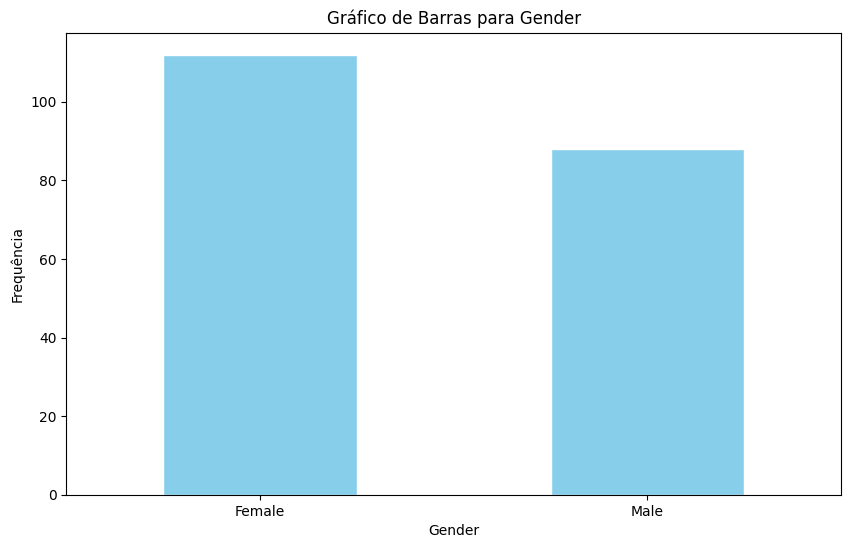

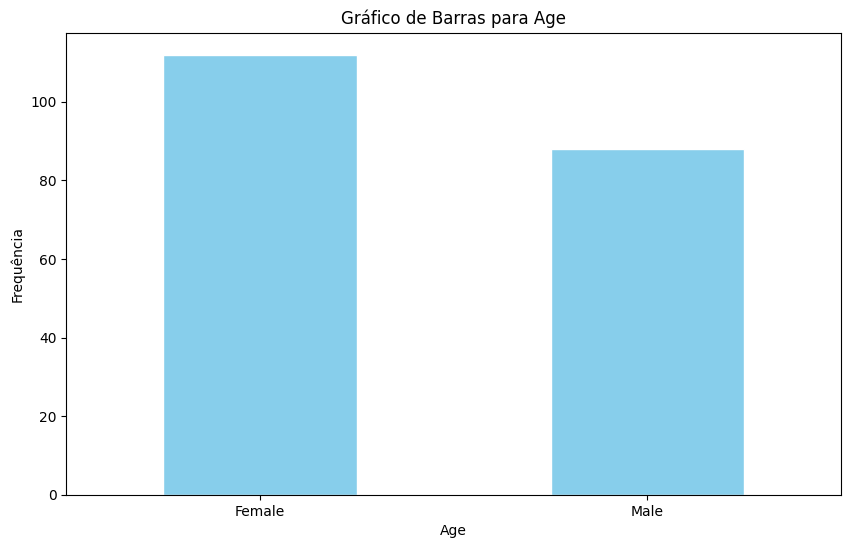

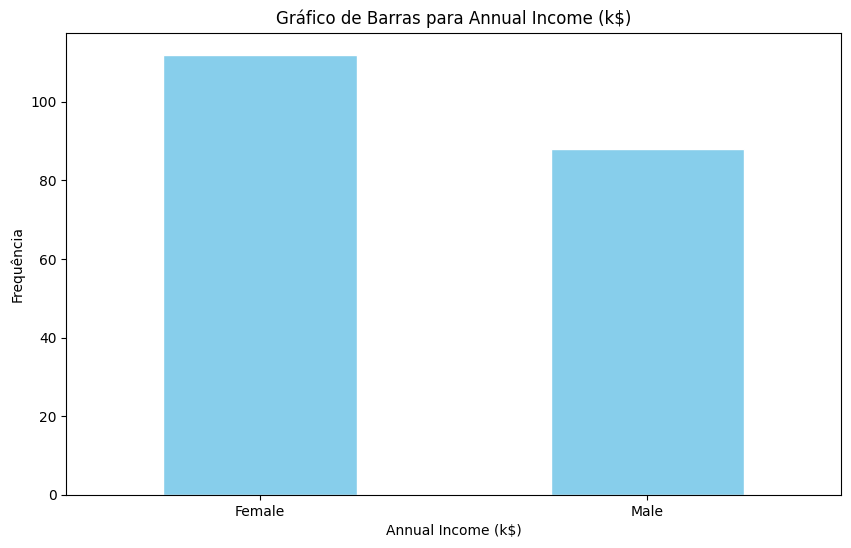

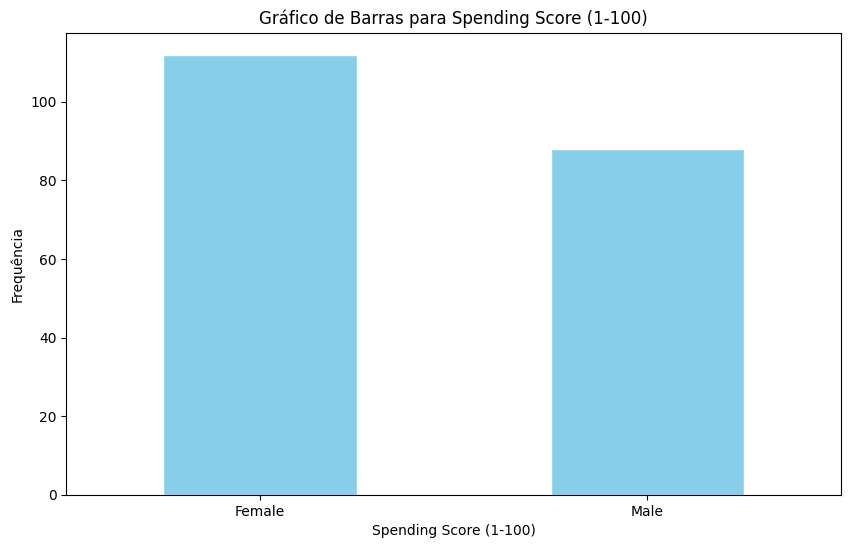

In [8]:
for campo in df:
    if df[campo].nunique() <= 10:  # Verifica se o campo é categórico
        contagem = df[campo].value_counts() 
    porcentagem = (contagem / contagem.sum()) * 100
    ax = contagem.plot(kind='bar', 
                       figsize=(10, 6), 
                       color='skyblue', 
                       edgecolor='white')
    plt.title(f'Gráfico de Barras para {campo}')
    plt.xticks(rotation=0)
    plt.xlabel(f'{campo}')
    plt.ylabel('Frequência')
    plt.show()

plt.close('all')


### Análise Exploratória - Possíveis Agrupamentos

Ao analisar os gráficos de distribuição das variáveis, o único agrupamento que se destaca, visualmente, é o da relação entre nota de gastos e receita anual. O gráfico mostra pelo menos 5 grupos. Esse valor pode ser usado para determinar o número de clusters do modelo.

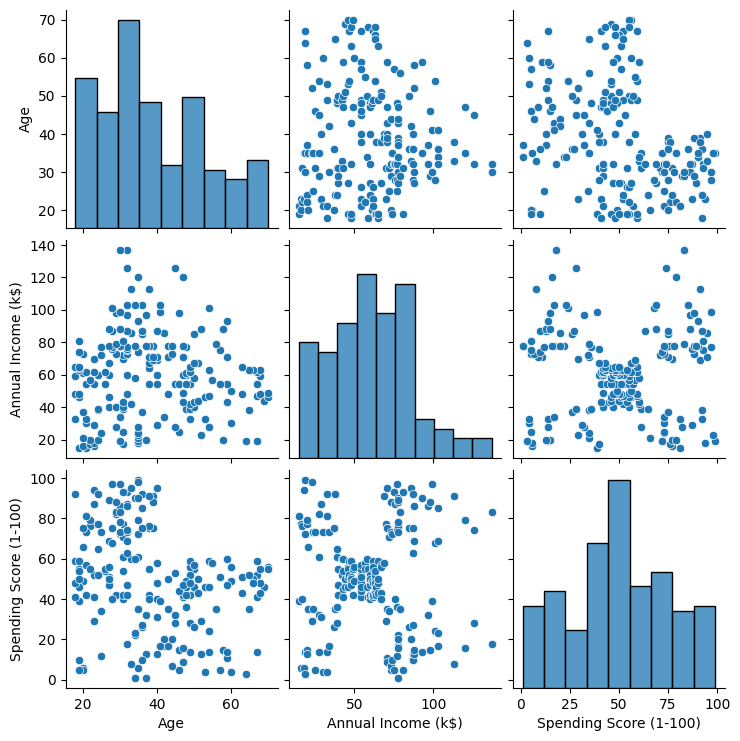

In [9]:
sns.pairplot(df)
plt.show()

## Tratamento de Dados

A partir da análise exploratória do item anterior, a única ação necessária, além do tratamento de outliers, é a transformação das variáveis categóricas em numéricas.

In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])
df.drop(['Gender'], axis = 1, inplace=True)
df.head(5)

,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


### Análise de Outliers

A anáslise estatística comentada anteriormente indicou a possibilidade de outlier na variável de receita anual (Annual Income). Para aprofundar esta análise, seguem abaixo a distribuição dos dados.

O histograma do campo indica quatro valores que se destacam dos outros, mas apenas um está acima do "upper bound", o limite superior do IQR. O box plot também indica apenas um valor superior.

Pela simplicidade, optou-se por excluir este valor.  

True

In [24]:
colunas = ['Annual Income (k$)']
for campo in colunas:
    fig = make_subplots(rows=1,
                    cols=2,
                    subplot_titles=[f'Histograma de {campo}',
                                        f'Box Plot de {campo}'])
    fig.add_trace(
    px.histogram(df,
                    x=campo, 
                    histnorm="percent", 
                    nbins=100).data[0],
    row=1, col=1
    )

    fig.add_trace(
    px.box(df, y=campo).data[0],
    row=1, col=2
    )

    
    if df[campo].dtype.kind in 'biufc':
        # IQR
        q1 = df[campo].quantile(0.25)
        q3 = df[campo].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        fig.add_hline(y=upper_bound, 
                line_dash="dash", 
                line_color="red", 
                row=1, col=2)
        
        
        fig.add_vline(x=upper_bound,
                line_dash="dash",
                line_color="red",
                row=1, col=1)
            

    fig.update_layout(title_text=f'{campo}', 
                    showlegend=False)
    fig.show()


In [11]:
df = df[df['Annual Income (k$)'] < upper_bound]
print(df.shape)

(198, 4)


## Balanceamento - Distribuição da Variável Alvo

O gráfico abaixo mostra a distribuição dos dados por nota. O comportamento em escada mostra um padrão desbalanceado, com muitos dados para as notas mais baixas, e menos dados para notas mais altas. Além disso, já é possível identificar possíveis grupos para nosso modelo de classificação, já que os dados parecem estar bem separados por grupos de notas.

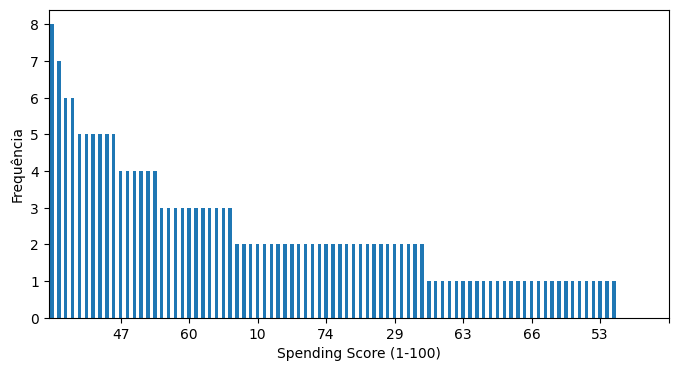

In [12]:
alvo_y = 'Spending Score (1-100)'
contagem_alvo = df[alvo_y].value_counts()
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel(alvo_y)
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)

plt.show()

### Corrigir balanceamento

Para a correção do balanceamento, optei por usar a técnica SMOTE, que promove o oversampling criando exemplos sintéticos da classe minoritária. Optei por aplicar essa estratégia por entender que ela balanceia os dados sem mudar a distribuição da população em relação a variável alvo. Ela se baseia na interpolação entre exemplos existentes da classe minoritária. 

Contudo, para funcionar, é preciso que todas as classes da variável y, Spending Score, tenham pelo menos duas amostras. Como é possível ver no histograma exibido anteriormente, isso não ocorre. Para driblar essa limitação, as notas serão agrupadas 

*Por esses motivos, sugiro que dois modelos sejam avaliados: um com os dados balanceados, outro como os dados originais.*

In [13]:
df_ampliado = pd.concat([df, df], ignore_index=True)
df_ampliado.shape

(396, 4)

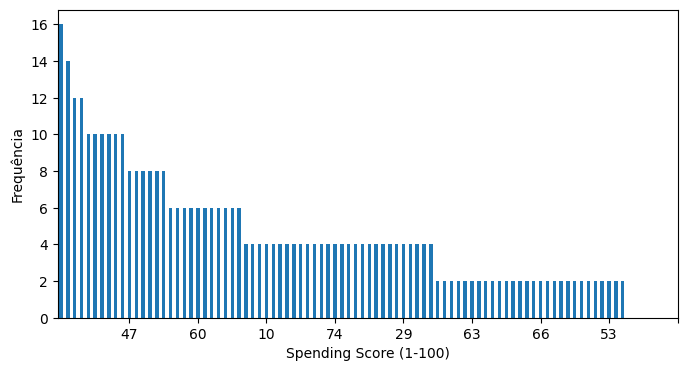

In [14]:
contagem_alvo = df_ampliado[alvo_y].value_counts()
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel(alvo_y)
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)
plt.show()

**Ao duplicar o df foi obtido um novo data frame com as cadacterísticas adequadas, sem, com isso, alterar a distribuição dos dados. Agora é possível aplicar o SMOTE.**

In [15]:
from imblearn.over_sampling import SMOTENC
alvo_y = 'Spending Score (1-100)'
x = df_ampliado.drop(alvo_y, axis=1)
y = df_ampliado[alvo_y]
# Verifique o índice da coluna categórica
gender_idx = x.columns.get_loc('Gender_encoded')

smoteNC = SMOTENC(categorical_features=[gender_idx], random_state=42, k_neighbors=1)
xb, yb = smoteNC.fit_resample(x, y)
print('Índice da coluna categórica:', gender_idx)
print(f"Dimensões após o balanceamento: {xb.shape}, {yb.shape}")

Índice da coluna categórica: 2
Dimensões após o balanceamento: (1328, 3), (1328,)


**Como é possível verificar abaixo, os dados foram equilibrados.**

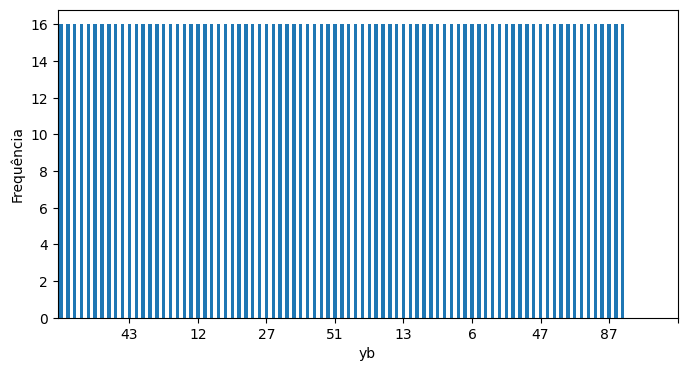

In [16]:
contagem_alvo = yb.value_counts()
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel("yb")
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)
plt.show()

**Feito o balanceamento, as variáveis serão agrupadas em um novo data frame. O K-means é um método de aprendizagem não supervisionado, ou seja, não deve ser separado em grupo treino e teste, nem variáveis alvo ou features.**

In [17]:
xb = pd.DataFrame(xb, columns=x.columns)
df_b = pd.concat([xb, yb], axis=1)
df_b.head(10)

,Age,Annual Income (k$),Gender_encoded,Spending Score (1-100)
0,19,15,1,39
1,21,15,1,81
2,20,16,0,6
3,23,16,0,77
4,31,17,0,40
5,22,17,0,76
6,35,18,0,6
7,23,18,0,94
8,64,19,1,3
9,30,19,0,72


**Para melhor performance do modelo, optou-se por padronizar os dados.** O campo Age foi excluído da padronização por ser uma variável categórica.

In [18]:
from sklearn.preprocessing import StandardScaler
colunas_padronizar = ['Annual Income (k$)', 'Spending Score (1-100)']
scaler = StandardScaler()
df_bp = df_b.copy()
df_bp[colunas_padronizar] = scaler.fit_transform(df_b[colunas_padronizar])
df_bp.head(10)

,Age,Annual Income (k$),Gender_encoded,Spending Score (1-100)
0,19,-1.673174,1,-0.404496
1,21,-1.673174,1,1.053696
2,20,-1.636547,0,-1.550218
3,23,-1.636547,0,0.914821
4,31,-1.599921,0,-0.369777
5,22,-1.599921,0,0.880102
6,35,-1.563295,0,-1.550218
7,23,-1.563295,0,1.505042
8,64,-1.526668,1,-1.654374
9,30,-1.526668,0,0.741227


## Implementação do K-means

O primeiro passo é a criação de um clustering usando apenas os campos Spending Score e Anual Income.

Por que apenas eles foram escolhidos?
> O único padrão de grupos identificados foi o da dispersão dessas variáveis.
>
> O número de clusters escolhido foi 5, como indicado no gráfico abaixo.


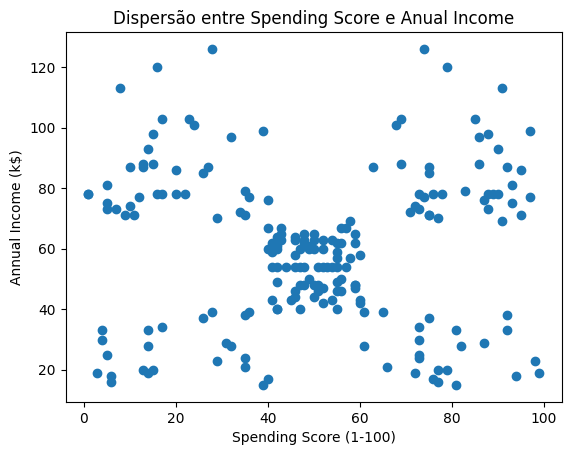

In [19]:
plt.scatter(df['Spending Score (1-100)'], df['Annual Income (k$)'])
plt.title("Dispersão entre Spending Score e Anual Income")
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Annual Income (k$)')
plt.show()

Serão feitos dois clusterings, um para as variáveis balanceadas, outra para os dados originais

In [ ]:
from sklearn.cluster import KMeans
# Dados Balanceados


c:\Users\marina.freitas\AppData\Local\anaconda3\envs\ebac\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



In [ ]:
kmeans_bp = KMeans(n_clusters=5, random_state=42)
X_bp = df_bp[['Annual Income (k$)', 'Spending Score (1-100)']]
ypredict_bp = kmeans_bp.fit_predict(X_bp)
cluster_bp_labels = kmeans_bp.labels_
centroides_bp = kmeans_bp.cluster_centers_  # Centroides no espaço padronizado
centroides_b = scaler.inverse_transform(centroides_bp) # Centroides no espaço original

# Dados Originais
kmeans_o = KMeans(n_clusters=5, random_state=42)
X_o = df[['Annual Income (k$)', 'Spending Score (1-100)']]
kmeans_o.fit_predict(X_o)
cluster_o_labels = kmeans_o.labels_
centroides_o = kmeans_o.cluster_centers_  # Centroides no espaço padronizado

### Comapração entre dados balanceados e não balanceados

In [21]:
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=['Clusters - Dados Balanceados', 
                                  'Clusters - Dados Originais'])

# Dados Balanceados
fig.add_trace(
    px.scatter(df_bp, 
              x='Annual Income (k$)', 
              y='Spending Score (1-100)', 
              opacity=0.7).data[0],
    row=1, col=1
)
# Centroides dos dados balanceados
fig.add_trace(
    go.Scatter(x=centroides_bp[:, 0], 
               y=centroides_bp[:, 1], 
               mode='markers',
               marker=dict(color='black', symbol='x', size=14),
               name='Centroides - Balanceado'),
    row=1, col=1
)

# Dados originais
fig.add_trace(
    px.scatter(df, 
              x='Annual Income (k$)', 
              y='Spending Score (1-100)', 
              opacity=0.7).data[0],
    row=2, col=1
)
# Centroides dos dados Originais
fig.add_trace(
    go.Scatter(x=centroides_o[:, 0], 
               y=centroides_o[:, 1], 
               mode='markers',
               marker=dict(color='black', symbol='x', size=14),
               name='Centroides - Original'),
    row=2, col=1
)

fig.update_layout(height=800, 
                 width=700,
                 showlegend=True,
                 title_text="Comparação dos Clusters")
fig.update_xaxes(title_text='Annual Income (k$)', row=1, col=1)
fig.update_xaxes(title_text='Annual Income (k$)', row=2, col=1)
fig.update_yaxes(title_text='Spending Score (1-100)', row=1, col=1)
fig.update_yaxes(title_text='Spending Score (1-100)', row=2, col=1)
fig.show()

Os centroides calculados para os dados balanceados se ajustaram de maneira muito mais natural e óbvia do que os dos dados originais. Essa comparação tornoua evidente a importância das transformações de balanceamento e padronização para esse conjunto de dados.

> Por esse motivo, a partir dessa etapa, só serão analisados os dados balanceados e padrnizados.

O próximo passo é analisar se há alguma relação entre esses grupos e as outras ariáveis independentes. Abaixo seguem os gráficos para essa análise. Os dados graficados serão os originais balanceados, sem a padronização, ne maneira a facilitar a análise.

In [22]:
# Relação com Gender
fig = px.scatter(df_bp, 
              x='Annual Income (k$)', 
              y='Spending Score (1-100)', 
              color='Gender_encoded', 
              color_discrete_sequence=px.colors.qualitative.Plotly, 
              opacity=0.7)
# Centroides
fig.add_scatter(
               x=centroides_bp[:, 0], 
               y=centroides_bp[:, 1], 
               mode='markers',
               marker=dict(color='black', symbol='x', size=14),
               name='Centroides')

fig.update_layout(height=600, 
                 width=800,
                 title_text="Comparação dos Clusters")

fig.show()


A partir da avaliação visual da distribuição de cores entre cada grupo é fácil afirmar que não há uma diferença de concentração considerável dde nenhum gênero em nenhum grupo, dado que as cores amarelo e azul parecem igualmente distribuídas.
> Por esse motivo, a análise de grupos em relação a gênero será encerrada.

In [23]:
# Relação com Age
fig = px.scatter(df_b, 
              x='Annual Income (k$)', 
              y='Spending Score (1-100)', 
              color='Age', 
              color_discrete_sequence=px.colors.qualitative.Plotly, 
              opacity=0.7)
# Centroides
fig.add_scatter(
               x=centroides_b[:, 0], 
               y=centroides_b[:, 1], 
               mode='markers',
               marker=dict(color='black', symbol='x', size=14),
               name='Centroides')

fig.update_layout(
    xaxis_title='Renda Anual (k$)',
    yaxis_title='Score de Gastos (1-100)',
)

É possível identificar um padrão dos tons de roxo a azul nos valores mais altos de pontuação de gastos para qualquer renda, mas especialmente para rendas muito altas ou muito baixas.

Os dois grupos com maior pontuação, nas pontas superiores do "X", concentram apenas clientes jovens, clientes com aproximadamente menos do que 40 anos. Clientes dessa faixa são encontrados também nos demais grupos.

Clientes com mais de 50 anos concentram-se nos outros 3 grupos, sendo que aqueles mais próximos de 70 anos se concentram no grupo central e no grupo inferior esquerdo.


> A partir dessa análise, sugere-se o aprofundamento da investigação da relação entre idade e pontuação de gastos.

#### K-means para Spending Score e Age

O gráfico abaixo mostra a dispersão entre Spending Score e Age. Não há nenhuma concentração evidente de pontos, mas, com algum esforço, é possível identificar entre 3 e 5 pequenos aglomerados.

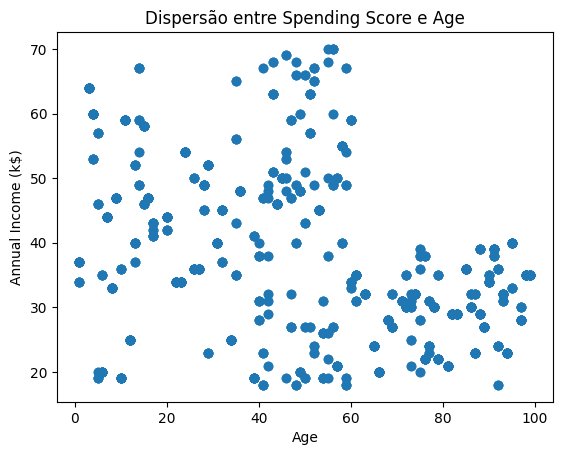

In [24]:
plt.scatter(df_b['Spending Score (1-100)'], df_b['Age'])
plt.title("Dispersão entre Spending Score e Age")
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()


Após a implementação do K-means e o teste para os valores 3, 4 e 5 de clusters, escolheu-se o valor 4 por mostrar um fit interessante entre os centróides e os aglomerados da disperção, como mostra o gráfico abaixo.

In [25]:
from sklearn.cluster import KMeans
# Dados Balanceados
kmeans_age = KMeans(n_clusters=4, random_state=42)
X_age = df_b[['Age', 'Spending Score (1-100)']]
kmeans_age.fit_predict(X_age)
cluster_age_labels = kmeans_age.labels_
centroides_age = kmeans_age.cluster_centers_  # Centroides no espaço original, pois não foram padronizados


In [26]:
fig = px.scatter(df_b, 
              x='Age', 
              y='Spending Score (1-100)',
              title="Spending Score v.s. Age")
# Centroides
fig.add_scatter(
               x=centroides_age[:, 0], 
               y=centroides_age[:, 1], 
               mode='markers',
               marker=dict(color='black', symbol='x', size=14),
               name='Centroides')

fig.update_layout(
    xaxis_title='Age',
    yaxis_title='Score de Gastos (1-100)',
    
)

## Avaliação dos Modelos kmeans_age e kmaenas_bp

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [47]:
# Suponha que X são os dados

inertia_bp = kmeans_bp.inertia_
silhouette_bp = silhouette_score(X_bp, kmeans_bp.labels_)
davies_bouldin_bp = davies_bouldin_score(X_bp,  kmeans_bp.labels_)
calinski_harabasz_bp = calinski_harabasz_score(X_bp,  kmeans_bp.labels_)

print("Métricas para Dados Balanceados:")
print(f'Inertia: {inertia_bp:.2f}')
print(f'Silhouette Score: {silhouette_bp:.2f}')
print(f'Davies-Bouldin Index: {davies_bouldin_bp:.2f}')
print(f'Calinski-Harabasz Index: {calinski_harabasz_bp:.2f}')



inertia_age = kmeans_age.inertia_
silhouette_age = silhouette_score(X_age, kmeans_age.labels_)
davies_bouldin_age = davies_bouldin_score(X_age,  kmeans_age.labels_)
calinski_harabasz_age = calinski_harabasz_score(X_age,  kmeans_age.labels_)

print("\nMétricas para K-Means com Age e Spending Score:")
print(f'Inertia: {inertia_age:.2f}')
print(f'Silhouette Score: {silhouette_age:.2f}')
print(f'Davies-Bouldin Index: {davies_bouldin_age:.2f}')
print(f'Calinski-Harabasz Index: {calinski_harabasz_age:.2f}')


Métricas para Dados Balanceados:
Inertia: 365.56
Silhouette Score: 0.57
Davies-Bouldin Index: 0.57
Calinski-Harabasz Index: 2072.31

Métricas para K-Means com Age e Spending Score:
Inertia: 203178.17
Silhouette Score: 0.49
Davies-Bouldin Index: 0.73
Calinski-Harabasz Index: 2424.88


### Métricas para a avaliação de um modelo Kmenas 

o valor de *inertia* indica a soma das distâncias quadráticas dos pontos ao centro do cluster. Por isso, quanto menor o valor, mais comapcto estão os clusters. Essa medida só compra valores entre diferentes modelos do mesmo dataset, então é um ponto de referência útil para comparar soluções. 

A *Silhouette Score* * indica a separação e coesão dos clusters. Ou seja, quão definidos estão os grupos de compradores. Já e métrica *Davies-Bouldin Index*, mede a similaridade entre os clusters. Assim, valores mais próximos de zero indicam maior separação e distinção entre eles. O índice *Calinski-Harabasz* indica maior qualidade, especialmente qundo a distinção e compactação dos clusters, quanto maior o seu valor.

#### Avaliação das previsões do modelo Kmeans para o Anual Income - kmeans_bp

O baixo valor de inertia indica que os dados estão compactados, bem como possui clusters estatisticamente distintos, como indicado pelo *Silhouette Score*.
Os resultados indicam que os clusters são estatisticamente distintos e agrupam clientes com diferentes perfis de compra. A separação e coesão indicam que a segmentação K-means capturou padrões relevantes nos dados, ajudando a identificar grupos de compradores para ações específicas. O baixo valor do índice *Davies-Bouldin* indica maior separação e distinção entre eles, enquanto o alto índice *Calinski-Harabasz* indicam clusters de alta qualidade.

#### Avaliação das previsões do modelo Kmeans para  o Age - kmeans_age 

Apesar deste modelo sepaarar os grupos de cleintes com uma qualidade considerável, elas é menos clara do que a do modelo anterior.

O alto valor de *inertiaI indica que os clusters não são tão compactos. Como o valor é bem maior do que no outro caso, isso pode indicar maior variabilidade nos dados ou que a escala dessas variáveis é maior. Já para a Silhouette Score (0.49), o valor próximo de 0.5 indica, assim com no modelo anteior, que os clusters possuem uma separação moderada, ou seja, que há mais sobreposição entre os clientes em diferenter grupos. Em acordo com o já indicado, a métrica *Davies-Bouldin*, por ter um valor mais alto do que antes, sugere maior similaridade entre clusters e, portanto, uma separação menos distinta. Já o alto valor da métrica *Calinski-Harabasz*, indica que, apesar da separação moderada, a variabilidade entre clusters está consideravelmente alta, o que pode indicar que clusters captam diferenças significativas dentro do segmento.